# 07. Tuning de modelos perdedores — Fase 5b

Los modelos que NO ganaron en Fase 4/5 se tunean con Optuna para ver si alcanzan al ganador
actual. **Bar a superar:** LightGBM nativo spw=1 (Fase 5) → **AUC-PR validación 0,0307**,
recall@top10% 0,669.

Contendientes (58 features, `tiene_avicena` excluida):
1. **XGBoost** (native, NaN nativo) — se tunea regularización y `scale_pos_weight` (incluye =1,
   por el hallazgo de Fase 5 de que reponderar degrada el ranking).
2. **LR-SMOTE** (impute + escalado) — tunea C, penalty, razones SMOTE.
3. **LR-balanced** (impute + escalado, class_weight='balanced') — tunea C, penalty.

Método: Optuna + GroupKFold(3) por `key`, objetivo AUC-PR out-of-fold sobre un subsample que
preserva prevalencia. Refit final + validación temporal 2023→2024 con train COMPLETO.

> **Reproducibilidad:** el tuning (Optuna) se ejecutó en el pipeline; aquí se **cargan** los
> hiperparámetros y la validación de `_resultados_sin_avicena.json`, y se **carga el modelo
> ganador** para confirmar su AUC-PR de validación de forma exacta.


In [1]:
import json, warnings
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")

import xgboost as xgb
import joblib
from sklearn.metrics import average_precision_score, roc_auc_score, precision_recall_curve

B = "bases"; RNG = 42
DROP = ['tiene_avicena']
RES = json.load(open(f"{B}/_resultados_sin_avicena.json", encoding="utf-8"))
F5B = RES['fase5b']
BAR_PR = F5B['bar_pr']            # bar Fase 5 (LGB-spw1-native)
BAR_TOP10 = RES['fase5']['validacion'][0]['recall@top10.0%']
print(f"Bar Fase 5: AUC-PR {BAR_PR} | recall@top10% {BAR_TOP10:.4f} | features {RES['n_features']}")


Bar Fase 5: AUC-PR 0.0307 | recall@top10% 0.6687 | features 58


In [2]:
nat_va = pd.read_parquet(f"{B}/prediccion_mama_val_native.parquet")
FEAT = [c for c in nat_va.columns if c not in ('key', 'label', *DROP)]
y_va = nat_va['label'].values.astype(int)
Xn_va = nat_va[FEAT].astype('float32').values
assert len(FEAT) == RES['n_features'], (len(FEAT), RES['n_features'])
print(f"val {Xn_va.shape} pos {y_va.sum()} | {len(FEAT)} feats (tiene_avicena excluida)")

def summarize(y, p, name):
    m = {'modelo': name, 'AUC_PR': float(average_precision_score(y, p)),
         'AUC_ROC': float(roc_auc_score(y, p))}
    for f in (0.005, 0.01, 0.05, 0.10):
        k = max(1, int(len(p) * f)); idx = np.argpartition(-p, k)[:k]
        m[f'recall@top{f*100:.1f}%'] = float(y[idx].sum() / y.sum())
    return m


val (2410807, 58) pos 993 | 58 feats (tiene_avicena excluida)


## 1. XGBoost (native) — hiperparámetros tuneados

40 trials Optuna, 3-fold GroupKFold. `scale_pos_weight` tunable en [1, 50] (log). Optuna eligió
una reponderación **leve** (spw≈3,6), coherente con Fase 5 (spw extremo degrada el ranking).


In [3]:
xgb_bp = F5B['xgb_best_params']
print("XGBoost best_params:")
for k, v in xgb_bp.items():
    print(f"  {k}: {v if isinstance(v, int) else round(v, 5)}")
print(f"\nAUC-PR CV (subsample, prevalencia mayor → no comparable al bar): {F5B['xgb_cv_auc_pr']:.4f}")


XGBoost best_params:
  n_estimators: 387
  learning_rate: 0.03462
  max_depth: 6
  min_child_weight: 20.82525
  subsample: 0.65205
  colsample_bytree: 0.60973
  gamma: 2.27875
  reg_alpha: 0.01337
  reg_lambda: 0.00627
  scale_pos_weight: 3.58709

AUC-PR CV (subsample, prevalencia mayor → no comparable al bar): 0.1172


## 2. LR-SMOTE (impute + escalado) — hiperparámetros tuneados

In [4]:
lrs_bp = F5B['lr_smote_best_params']
print("LR-SMOTE best_params:", lrs_bp)
print(f"AUC-PR CV: {F5B['lr_smote_cv']:.4f}")


LR-SMOTE best_params: {'C': 0.034554457756490825, 'penalty': 'l1', 'under_ratio': 0.08410213036763374, 'smote_ratio': 0.3043107770998088}
AUC-PR CV: 0.0501


## 3. LR-balanced (impute + escalado) — hiperparámetros tuneados

In [5]:
lrb_bp = F5B['lr_balanced_best_params']
print("LR-balanced best_params:", lrb_bp)
print(f"AUC-PR CV: {F5B['lr_balanced_cv']:.4f}")


LR-balanced best_params: {'C': 0.0010886945632263792, 'penalty': 'l1'}
AUC-PR CV: 0.0479


## 4. Validación temporal 2023→2024 (test final)

Cada modelo reajustado en train completo y evaluado una sola vez en validación, contra el bar de
Fase 5. El **modelo ganador se carga y se re-evalúa aquí** para confirmar el número canónico.


In [6]:
comp = pd.DataFrame(F5B['validacion']).set_index('modelo').sort_values('AUC_PR', ascending=False)
pd.set_option('display.width', 200, 'display.max_columns', 20)
print("=== Validación 2023→2024 (Fase 5b) ===")
print(comp.to_string(float_format='{:.4f}'.format))
print(f"\nBar (LightGBM nativo spw=1, Fase 5): AUC-PR {BAR_PR}, recall@top10% {BAR_TOP10:.4f}")
best_name = comp['AUC_PR'].idxmax()
best_pr = comp.loc[best_name, 'AUC_PR']
print(f"Mejor: {best_name} (AUC-PR {best_pr:.4f}) -> {'SUPERA el bar' if best_pr > BAR_PR else 'NO supera'}")


=== Validación 2023→2024 (Fase 5b) ===
                      AUC_PR  AUC_ROC  recall@top0.5%  recall@top1.0%  recall@top5.0%  recall@top10.0%
modelo                                                                                                
XGBoost-tuned-native  0.0388   0.9007          0.2739          0.3333          0.5680           0.6989
LR-SMOTE-tuned        0.0100   0.8764          0.2044          0.2669          0.4914           0.6294
LR-balanced-tuned     0.0094   0.8687          0.2054          0.2689          0.4854           0.6193

Bar (LightGBM nativo spw=1, Fase 5): AUC-PR 0.0307, recall@top10% 0.6687
Mejor: XGBoost-tuned-native (AUC-PR 0.0388) -> SUPERA el bar


Confirmación modelo cargado:
  AUC-PR 0.0388 (canónico 0.0388)
  recall@top10% 0.6989 | top5% 0.5680 | top1% 0.3333


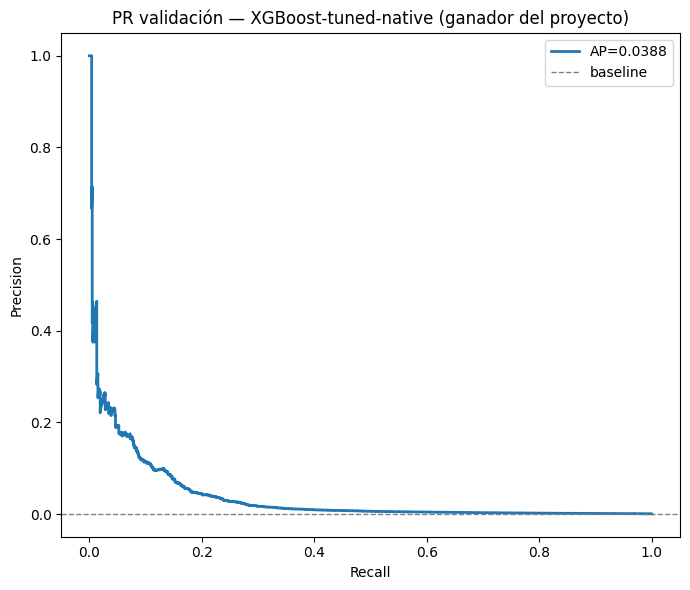

In [7]:
# Confirmación: cargar el modelo ganador y re-evaluar en validación (exacto, determinístico)
m_xgb = joblib.load(f"{B}/modelo_fase5b_XGBoost-tuned-native.joblib")
p_xgb = m_xgb.predict_proba(Xn_va)[:, 1]
chk = summarize(y_va, p_xgb, 'XGBoost-tuned-native (recargado)')
print("Confirmación modelo cargado:")
print(f"  AUC-PR {chk['AUC_PR']:.4f} (canónico {comp.loc['XGBoost-tuned-native','AUC_PR']:.4f})")
print(f"  recall@top10% {chk['recall@top10.0%']:.4f} | top5% {chk['recall@top5.0%']:.4f} | "
      f"top1% {chk['recall@top1.0%']:.4f}")

prec, rec, _ = precision_recall_curve(y_va, p_xgb)
plt.figure(figsize=(7, 6))
plt.plot(rec, prec, lw=2, label=f"AP={chk['AUC_PR']:.4f}")
plt.axhline(y_va.mean(), ls='--', c='gray', lw=1, label='baseline')
plt.xlabel('Recall'); plt.ylabel('Precision')
plt.title('PR validación — XGBoost-tuned-native (ganador del proyecto)')
plt.legend(); plt.tight_layout(); plt.show()


## 5. Conclusión Fase 5b

**🏆 GANADOR DEL PROYECTO: XGBoost-tuned-native** (58 features, sin `tiene_avicena`) —
AUC-PR val **0,0388** (supera el bar 0,0307, +26%), recall@top10% **0,699**. Los lineales
(LR-SMOTE/LR-balanced ≈0,010) no capturan la no-linealidad y quedan muy atrás.

`scale_pos_weight≈3,6` (moderado) confirma que la reponderación leve no daña el ranking, pero
los valores extremos sí (Fase 5). Artefacto: `bases/modelo_fase5b_XGBoost-tuned-native.joblib`.
